In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

import cosmic.utils as cu
from photoz_bin import PhotozBinInference, Config

print(os.getcwd())
DELTACHI2_THRESHOLD = 25
if DELTACHI2_THRESHOLD > 25:
    EXPERIMENT_DIR = f"./DESIDR1_xSDSSDR19/testDELTACHI2_BasedOnMag&MagErr/{DELTACHI2_THRESHOLD}" 
else:
    EXPERIMENT_DIR = "./grizW1W2/Mag&MagErr"
print('Operation directory:', EXPERIMENT_DIR)
CALIBRATOR_DIR = f"{EXPERIMENT_DIR}/TempScalingCalib"
print('Calibrator directory:', CALIBRATOR_DIR)

# LSDR9x10 grizW1W2
TRAINSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_i_train.fits"
VALSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_i_val.fits"
TESTSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_i_test.fits"
# LSDR9x10 grzW1W2
# TRAINSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_train.fits"
# VALSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_val.fits"
# TESTSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_test.fits"
# LSDR9x10 grizW1W2 DESI only
# TRAINSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_i_train_DESIonly_train.fits"
# VALSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_i_train_DESIonly_val.fits"
# LSDR9x10 grizW1W2 SDSS only
# TRAINSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_i_train_SDSSonly_train.fits"
# VALSET_PATH = "/home/tiandc/photoz/lsdr9x10/data/DESIDR1_xSDSSDR19_xlsdr9x10Phot_clean_i_train_SDSSonly_val.fits"

/home/tiandc/photoz/lsdr9x10/photoz_bin
Operation directory: ./grizW1W2/Mag&MagErr
Calibrator directory: ./grizW1W2/Mag&MagErr/TempScalingCalib


# Predict

Config loaded from: ./grizW1W2/Mag/config.yaml
Using device: cuda:0
Dataset params: {'binning_config': {'z_min': 0.0, 'z_max': 2, 'num_bins': 400, 'soft_label_width': 0.1}, 'feature_columns': ['dered_mag_g', 'dered_mag_r', 'dered_mag_i', 'dered_mag_z', 'dered_mag_w1', 'dered_mag_w2']}
Model params: {'hidden_dims': [512, 256, 128, 64], 'dropout_rate': 0.1, 'activation_function': 'relu', 'use_batch_norm': True, 'use_layer_norm': False, 'use_residual': True}
Running inference from file paths (expectation mode)...
Inference completed
  Trainset predictions range: [0.0207, 1.6943]
  Trainset labels range: [0.0000, 1.9777]
  Valset predictions range: [0.0227, 1.4531]
  Valset labels range: [0.0000, 1.9569]
  Testset predictions range: [0.0227, 1.4759]
  Testset labels range: [0.0000, 1.7717]

Metric          Trainset     Valset       Testset     
<Δz_norm>       -0.000298    -0.000303    -0.000323   
std             0.024634     0.024759     0.024672    
mad             0.016464     0.016457

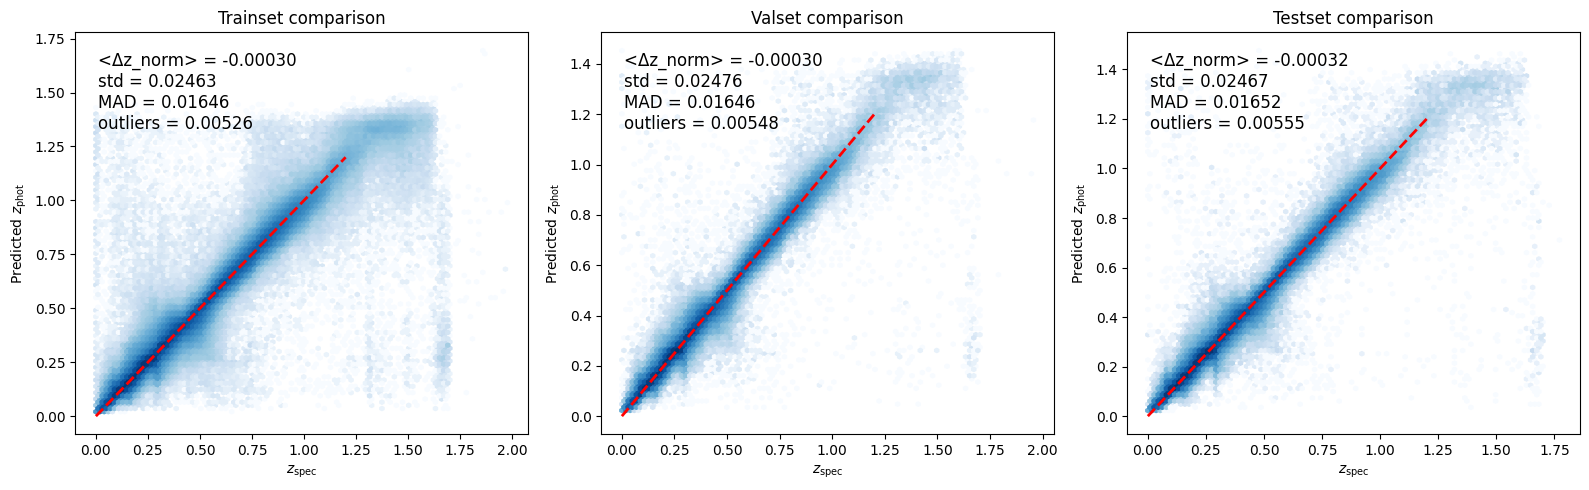

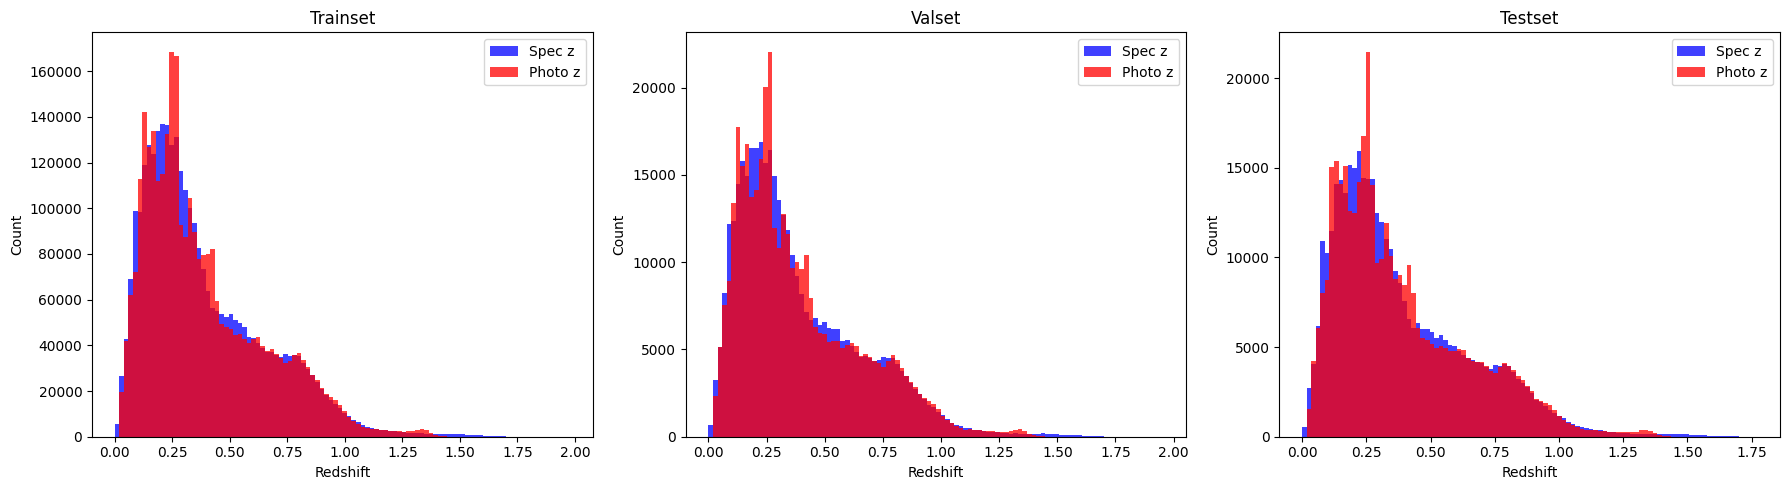

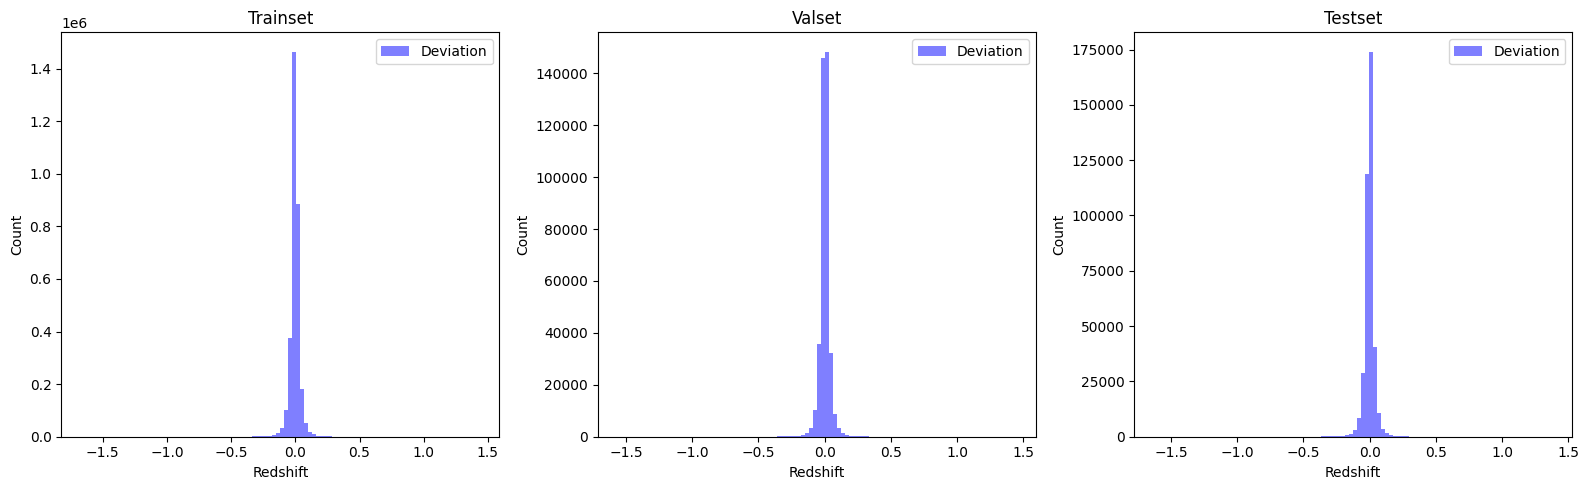

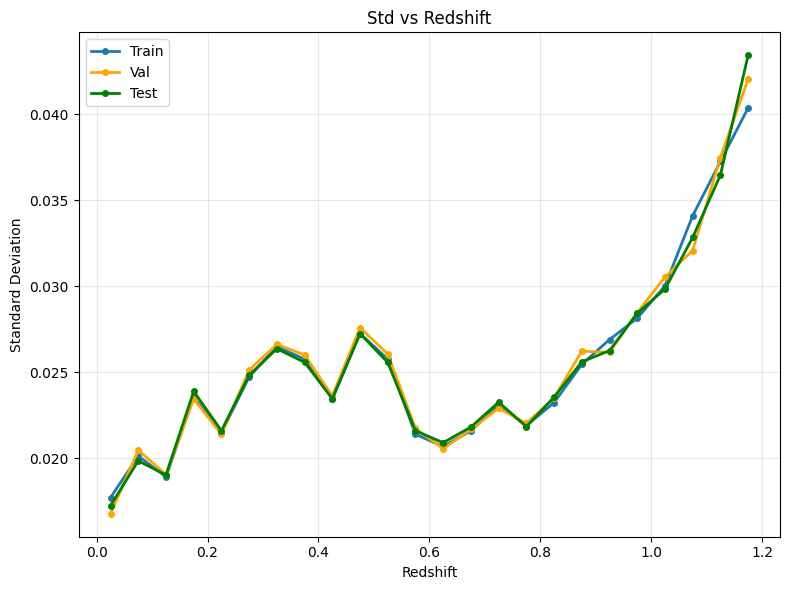

In [7]:
# model and config (binned classifier inference)
# Control prediction mode: 'expectation' or 'sample'
PREDICT_MODE = 'expectation'  # change to 'sample' for sampling-based histogram
_PRED_KEY = 'expectation' if PREDICT_MODE == 'sample' else 'expectation'
RANDOM_SEED = 42
config_path = f"{EXPERIMENT_DIR}/config.yaml"

config = Config()
config.update_from_yaml(config_path)
print(f"Config loaded from: {config_path}")

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print(f"Dataset params: {config.dataset_params}")
print(f"Model params: {config.model_params}")

# Initialize inference helper (loads scaler and model internally)
infer = PhotozBinInference(model_dir=EXPERIMENT_DIR, device=device, batch_size=4096)


print(f"Running inference from file paths ({PREDICT_MODE} mode)...")

train_df = cu.readfile(TRAINSET_PATH)
val_df = cu.readfile(VALSET_PATH)
test_df = cu.readfile(TESTSET_PATH)

train_labels = train_df['z'].values
val_labels = val_df['z'].values
test_labels = test_df['z'].values

# Expectation for metrics/hexbin
train_preds = infer.predict(TRAINSET_PATH, mode='expectation')['expectation']
val_preds = infer.predict(VALSET_PATH, mode='expectation')['expectation']
test_preds = infer.predict(TESTSET_PATH, mode='expectation')['expectation']

# Histogram predictions: sample if requested, otherwise expectation
if PREDICT_MODE == 'sample':
    train_preds_hist = infer.predict(TRAINSET_PATH, mode='sample', seed=RANDOM_SEED)['sample']
    val_preds_hist = infer.predict(VALSET_PATH, mode='sample', seed=RANDOM_SEED)['sample']
    test_preds_hist = infer.predict(TESTSET_PATH, mode='sample', seed=RANDOM_SEED)['sample']
else:
    train_preds_hist = train_preds
    val_preds_hist = val_preds
    test_preds_hist = test_preds

print(f"Inference completed")
print(f"  Trainset predictions range: [{train_preds.min():.4f}, {train_preds.max():.4f}]")
print(f"  Trainset labels range: [{train_labels.min():.4f}, {train_labels.max():.4f}]")
print(f"  Valset predictions range: [{val_preds.min():.4f}, {val_preds.max():.4f}]")
print(f"  Valset labels range: [{val_labels.min():.4f}, {val_labels.max():.4f}]")
print(f"  Testset predictions range: [{test_preds.min():.4f}, {test_preds.max():.4f}]")
print(f"  Testset labels range: [{test_labels.min():.4f}, {test_labels.max():.4f}]")

prediction_train = np.vstack((train_labels, train_preds)).T
prediction_train_df = pd.DataFrame(prediction_train, columns=['label', 'pred'])
path = f"{EXPERIMENT_DIR}/predictions_train.fits"
cu.savefile(prediction_train_df, path)

prediction_val = np.vstack((val_labels, val_preds)).T
prediction_val_df = pd.DataFrame(prediction_val, columns=['label', 'pred'])
path = f"{EXPERIMENT_DIR}/predictions_val.fits"
cu.savefile(prediction_val_df, path)

prediction_test = np.vstack((test_labels, test_preds)).T
prediction_test_df = pd.DataFrame(prediction_test, columns=['label', 'pred'])
path = f"{EXPERIMENT_DIR}/predictions_test.fits"
cu.savefile(prediction_test_df, path)

# metrics
train_path = f"{EXPERIMENT_DIR}/predictions_train.fits"
val_path = f"{EXPERIMENT_DIR}/predictions_val.fits"
test_path = f"{EXPERIMENT_DIR}/predictions_test.fits"
train_df = cu.readfile(train_path)
val_df = cu.readfile(val_path)
test_df = cu.readfile(test_path)

train_labels = train_df['label'].values
train_preds = train_df['pred'].values
val_labels = val_df['label'].values
val_preds = val_df['pred'].values
test_labels = test_df['label'].values
test_preds = test_df['pred'].values

train_metrics = cu.evaluate_redshift_quality(train_labels, train_preds)
val_metrics = cu.evaluate_redshift_quality(val_labels, val_preds)
test_metrics = cu.evaluate_redshift_quality(test_labels, test_preds)

print("\n" + "="*60)
print(f"{'Metric':<15} {'Trainset':<12} {'Valset':<12} {'Testset':<12}")
print("="*60)
print(f"{'<Δz_norm>':<15} {train_metrics['mean_bias']:<12.6f} {val_metrics['mean_bias']:<12.6f} {test_metrics['mean_bias']:<12.6f}")
print(f"{'std':<15} {train_metrics['std_dev']:<12.6f} {val_metrics['std_dev']:<12.6f} {test_metrics['std_dev']:<12.6f}")
print(f"{'mad':<15} {train_metrics['mad']:<12.6f} {val_metrics['mad']:<12.6f} {test_metrics['mad']:<12.6f}")
print(f"{'outliers':<15} {train_metrics['outlier_fraction']:<12.6f} {val_metrics['outlier_fraction']:<12.6f} {test_metrics['outlier_fraction']:<12.6f}")
print("="*60)


# plot
plt.figure(figsize=(16, 5))

plt.subplot(131)
plt.hexbin(train_labels, train_preds, gridsize=100, bins='log', cmap='Blues', mincnt=1)
plt.plot([0, 1.2], [0, 1.2], 'r--', lw=2)
plt.xlabel(r'$z_\mathrm{spec}$')
plt.ylabel(r'$\mathrm{Predicted}\ z_\mathrm{phot}$')
plt.title('Trainset comparison')
text = f'<Δz_norm> = {train_metrics['mean_bias']:.5f}\nstd = {train_metrics['std_dev']:.5f}\nMAD = {train_metrics['mad']:.5f}\noutliers = {train_metrics['outlier_fraction']:.5f}'
plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)

plt.subplot(132)
plt.hexbin(val_labels, val_preds, gridsize=100, bins='log', cmap='Blues', mincnt=1)
plt.plot([0, 1.2], [0, 1.2], 'r--', lw=2)
plt.xlabel(r'$z_\mathrm{spec}$')
plt.ylabel(r'$\mathrm{Predicted}\ z_\mathrm{phot}$')
plt.title('Valset comparison')
text = f'<Δz_norm> = {val_metrics['mean_bias']:.5f}\nstd = {val_metrics['std_dev']:.5f}\nMAD = {val_metrics['mad']:.5f}\noutliers = {val_metrics['outlier_fraction']:.5f}'
plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)

plt.subplot(133)
plt.hexbin(test_labels, test_preds, gridsize=100, bins='log', cmap='Blues', mincnt=1)
plt.plot([0, 1.2], [0, 1.2], 'r--', lw=2)
plt.xlabel(r'$z_\mathrm{spec}$')
plt.ylabel(r'$\mathrm{Predicted}\ z_\mathrm{phot}$')
plt.title('Testset comparison')
text = f'<Δz_norm> = {test_metrics['mean_bias']:.5f}\nstd = {test_metrics['std_dev']:.5f}\nMAD = {test_metrics['mad']:.5f}\noutliers = {test_metrics['outlier_fraction']:.5f}'
plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)

plt.tight_layout()

path = f"{EXPERIMENT_DIR}/results.jpg"
plt.savefig(path)


# redshift distribution
plt.figure(figsize=(18, 5))
# trainset
bins_train = np.linspace(
    min(train_labels.min(), train_preds_hist.min()),
    max(train_labels.max(), train_preds_hist.max()),
    101)
plt.subplot(131)
plt.hist(train_labels, bins=bins_train, alpha=0.75, label='Spec z', color='blue')
plt.hist(train_preds_hist, bins=bins_train, alpha=0.75, label='Photo z', color='red')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Trainset')
plt.legend()

# valset
bins_val = np.linspace(
    min(val_labels.min(), val_preds_hist.min()),
    max(val_labels.max(), val_preds_hist.max()),
    101)
plt.subplot(132)
plt.hist(val_labels, bins=bins_val, alpha=0.75, label='Spec z', color='blue')
plt.hist(val_preds_hist, bins=bins_val, alpha=0.75, label='Photo z', color='red')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Valset')
plt.legend()

# testset
bins_test = np.linspace(
    min(test_labels.min(), test_preds_hist.min()),
    max(test_labels.max(), test_preds_hist.max()),
    101)
plt.subplot(133)
plt.hist(test_labels, bins=bins_test, alpha=0.75, label='Spec z', color='blue')
plt.hist(test_preds_hist, bins=bins_test, alpha=0.75, label='Photo z', color='red')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Testset')
plt.legend()
plt.tight_layout()

path = f"{EXPERIMENT_DIR}/results_hist.jpg"
plt.savefig(path)


# deviation distribution
plt.figure(figsize=(16, 5))

plt.subplot(131)
dev = train_preds - train_labels
plt.hist(dev, bins=100, alpha=0.5, label='Deviation', color='blue')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Trainset')
plt.legend()

plt.subplot(132)
dev = val_preds - val_labels
plt.hist(dev, bins=100, alpha=0.5, label='Deviation', color='blue')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Valset')
plt.legend()

plt.subplot(133)
dev = test_preds - test_labels
plt.hist(dev, bins=100, alpha=0.5, label='Deviation', color='blue')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Testset')
plt.legend()

plt.tight_layout()

path = f"{EXPERIMENT_DIR}/results_dev.jpg"
plt.savefig(path)


# std vs redshift
z_min, z_max, z_step = 0.0, 1.2, 0.05
z_bins = np.arange(z_min, z_max + z_step, z_step)
z_centers = (z_bins[:-1] + z_bins[1:]) / 2

def calculate_bin_std(labels, preds, bins):
    """Calculate standard deviation for each redshift bin"""
    bin_indices = np.digitize(labels, bins)
    std_values = []
    counts = []
    
    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            bin_preds = preds[mask]
            bin_labels = labels[mask]
            std_val = cu.evaluate_redshift_quality(bin_labels, bin_preds)['std_dev']
            std_values.append(std_val)
            counts.append(np.sum(mask))
        else:
            std_values.append(np.nan)
            counts.append(0)
    
    return np.array(std_values), np.array(counts)

train_std, train_counts = calculate_bin_std(train_labels, train_preds, z_bins)
val_std, val_counts = calculate_bin_std(val_labels, val_preds, z_bins)
test_std, test_counts = calculate_bin_std(test_labels, test_preds, z_bins)

plt.figure(figsize=(8, 6))
plt.plot(z_centers, train_std, 'o-', label='Train', linewidth=2, markersize=4)
plt.plot(z_centers, val_std, 'o-', label='Val', linewidth=2, markersize=4, color='orange')
plt.plot(z_centers, test_std, 'o-', label='Test', linewidth=2, markersize=4, color='green')
plt.xlabel('Redshift')
plt.ylabel('Standard Deviation')
plt.title('Std vs Redshift')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

path = f"{EXPERIMENT_DIR}/std_vs_redshift.jpg"
plt.savefig(path, dpi=150, bbox_inches='tight')

In [8]:
# predict probabilities
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
infer = PhotozBinInference(model_dir=EXPERIMENT_DIR, 
                           device=device, batch_size=4096)

save_path = os.path.join(EXPERIMENT_DIR, 'predictions_test_prob.h5')
infer.predict_probabilities_chunked(TESTSET_PATH, save_path,
                                    chunk_size=1000000, 
                                    batch_size=4096,
                                    compression='gzip',
                                    apply_calibration=False)

Processing 396,361 samples with 400 bins...
Temperature scaling: disabled
Estimated uncompressed size: 0.63 GB
Processed 396,361/396,361 samples
Results saved to ./grizW1W2/Mag/predictions_test_prob.h5


## Predict with temperature scaling calibration

Config loaded from: ./grizW1W2/Mag/config.yaml
Using device: cuda:0
Dataset params: {'binning_config': {'z_min': 0.0, 'z_max': 2, 'num_bins': 400, 'soft_label_width': 0.1}, 'feature_columns': ['dered_mag_g', 'dered_mag_r', 'dered_mag_i', 'dered_mag_z', 'dered_mag_w1', 'dered_mag_w2']}
Model params: {'hidden_dims': [512, 256, 128, 64], 'dropout_rate': 0.1, 'activation_function': 'relu', 'use_batch_norm': True, 'use_layer_norm': False, 'use_residual': True}
Running inference from file paths (expectation mode)...
Before calibration: KS=0.0164 | Good calibration.
After calibration (T=0.9037): KS=0.0044 | Excellent calibration.
Plot saved to grizW1W2/Mag/TempScalingCalib/calibrator.png


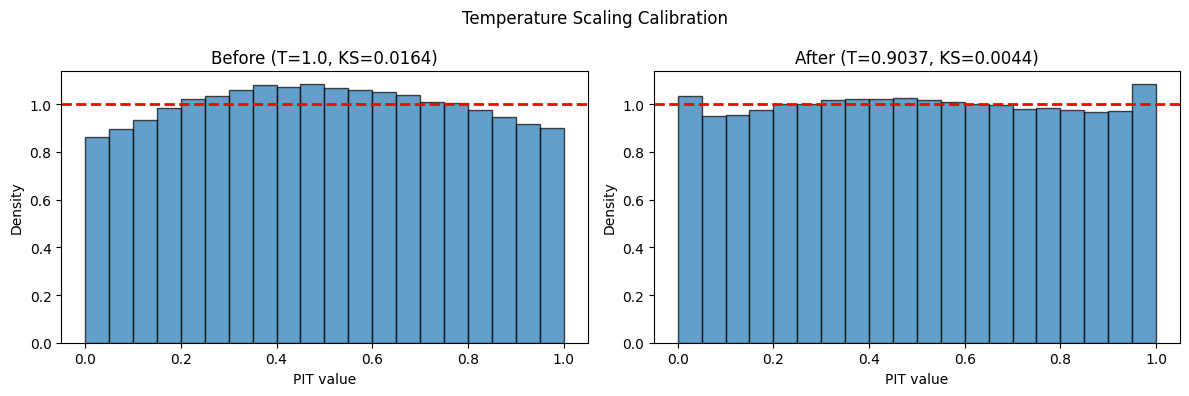

Calibrator saved to grizW1W2/Mag/TempScalingCalib/calibrator.pkl
Calibrator loaded: T=0.9037
Inference completed (metrics=expectation, histogram=expectation)
Inference completed
  Trainset predictions range: [0.0157, 1.7218]
  Trainset labels range: [0.0000, 1.9777]
  Valset predictions range: [0.0226, 1.4689]
  Valset labels range: [0.0000, 1.9569]
  Testset predictions range: [0.0226, 1.5304]
  Testset labels range: [0.0000, 1.7717]

Metric          Trainset     Valset       Testset     
<Δz_norm>       -0.000127    -0.000133    -0.000144   
std             0.024529     0.024676     0.024579    
mad             0.016259     0.016265     0.016316    
outliers        0.005321     0.005546     0.005609    


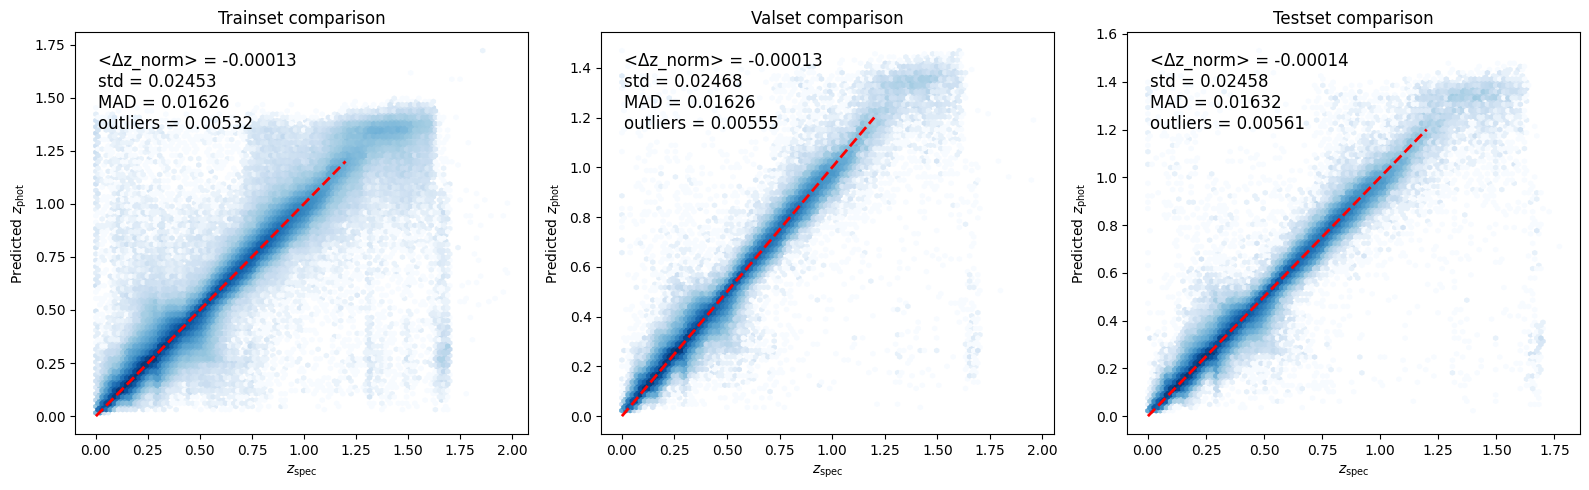

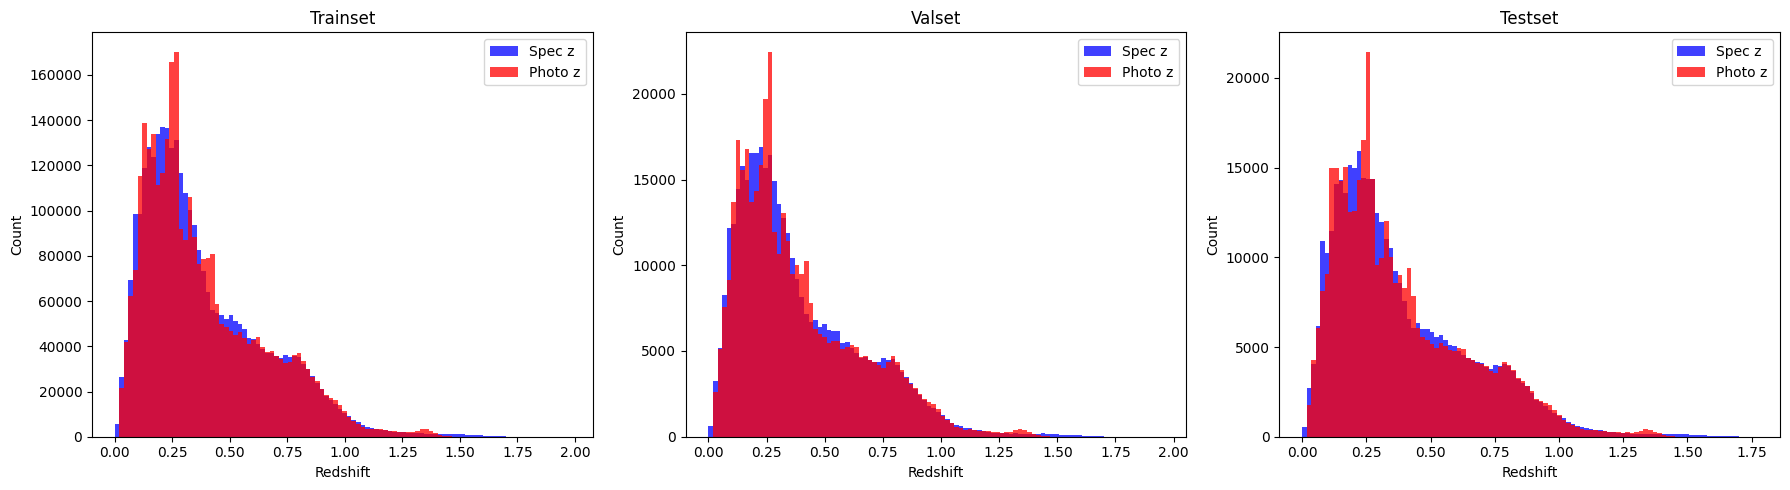

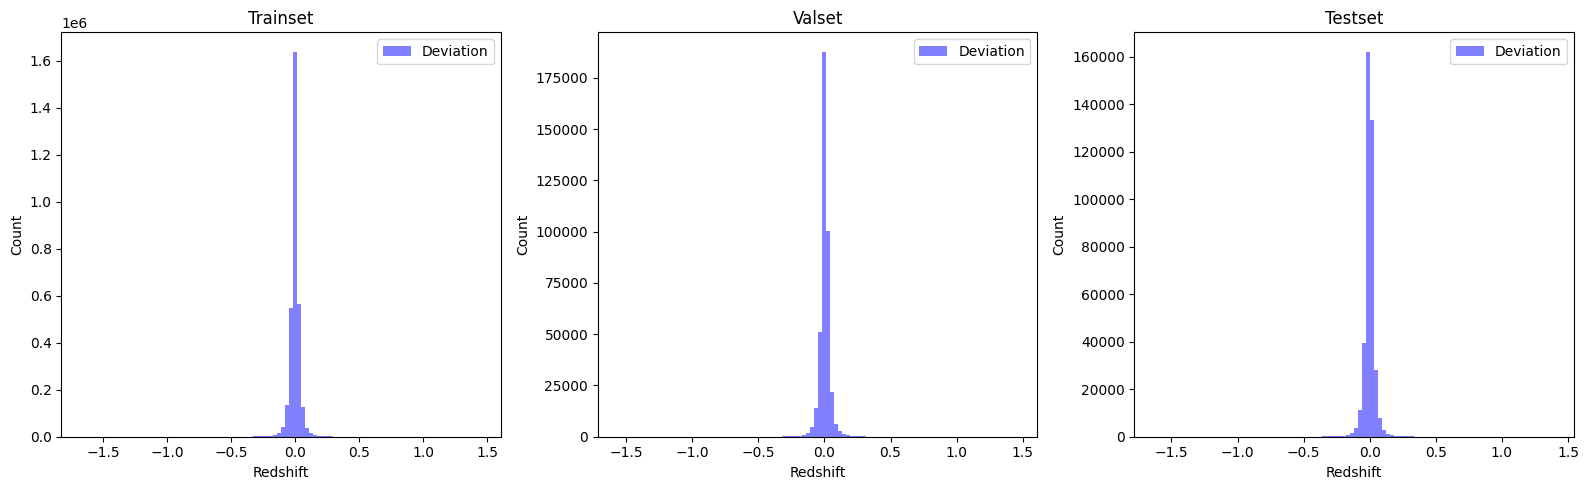

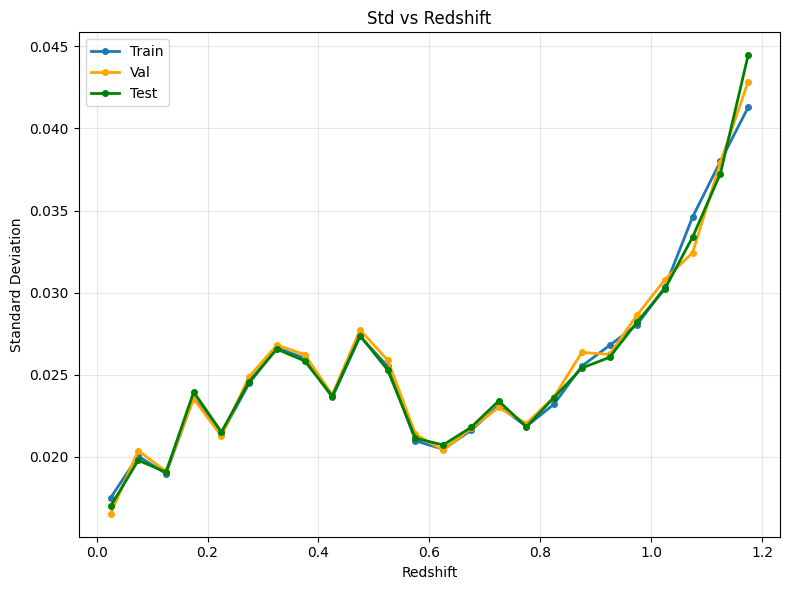

In [9]:
CALIBRATOR_DIR = f"{EXPERIMENT_DIR}/TempScalingCalib"
os.makedirs(CALIBRATOR_DIR, exist_ok=True)

# model and config (binned classifier inference)
# Control prediction mode: 'expectation' or 'sample'
PREDICT_MODE = 'expectation'  # change to 'sample' for sampling-based histogram
_PRED_KEY = 'expectation' if PREDICT_MODE == 'sample' else 'expectation'
RANDOM_SEED = 42
config_path = f"{EXPERIMENT_DIR}/config.yaml"

config = Config()
config.update_from_yaml(config_path)
print(f"Config loaded from: {config_path}")

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print(f"Dataset params: {config.dataset_params}")
print(f"Model params: {config.model_params}")
print(f"Running inference from file paths ({PREDICT_MODE} mode)...")

train_df = cu.readfile(TRAINSET_PATH)
val_df = cu.readfile(VALSET_PATH)
test_df = cu.readfile(TESTSET_PATH)

train_labels = train_df['z'].values
val_labels = val_df['z'].values
test_labels = test_df['z'].values

# Initialize inference helper (loads scaler and model internally)
infer = PhotozBinInference(model_dir=EXPERIMENT_DIR, device=device, batch_size=4096)
# Temperature scaling calibration
infer.calibrate(data_source=VALSET_PATH, save_path=f"{CALIBRATOR_DIR}/calibrator")
infer.load_calibrator(f"{CALIBRATOR_DIR}/calibrator.pkl")

# Expectation for metrics/hexbin
train_preds = infer.predict(TRAINSET_PATH, mode='expectation')['expectation']
val_preds = infer.predict(VALSET_PATH, mode='expectation')['expectation']
test_preds = infer.predict(TESTSET_PATH, mode='expectation')['expectation']

# Histogram predictions: sample if requested, otherwise expectation
if PREDICT_MODE == 'sample':
    train_preds_hist = infer.predict(TRAINSET_PATH, mode='sample', seed=RANDOM_SEED)['sample']
    val_preds_hist = infer.predict(VALSET_PATH, mode='sample', seed=RANDOM_SEED)['sample']
    test_preds_hist = infer.predict(TESTSET_PATH, mode='sample', seed=RANDOM_SEED)['sample']
else:
    train_preds_hist = train_preds
    val_preds_hist = val_preds
    test_preds_hist = test_preds

print(f"Inference completed (metrics=expectation, histogram={PREDICT_MODE})")

print(f"Inference completed")
print(f"  Trainset predictions range: [{train_preds.min():.4f}, {train_preds.max():.4f}]")
print(f"  Trainset labels range: [{train_labels.min():.4f}, {train_labels.max():.4f}]")
print(f"  Valset predictions range: [{val_preds.min():.4f}, {val_preds.max():.4f}]")
print(f"  Valset labels range: [{val_labels.min():.4f}, {val_labels.max():.4f}]")
print(f"  Testset predictions range: [{test_preds.min():.4f}, {test_preds.max():.4f}]")
print(f"  Testset labels range: [{test_labels.min():.4f}, {test_labels.max():.4f}]")

prediction_train = np.vstack((train_labels, train_preds)).T
prediction_train_df = pd.DataFrame(prediction_train, columns=['label', 'pred'])
path = f"{CALIBRATOR_DIR}/predictions_train.fits"
cu.savefile(prediction_train_df, path)

prediction_val = np.vstack((val_labels, val_preds)).T
prediction_val_df = pd.DataFrame(prediction_val, columns=['label', 'pred'])
path = f"{CALIBRATOR_DIR}/predictions_val.fits"  
cu.savefile(prediction_val_df, path)

prediction_test = np.vstack((test_labels, test_preds)).T
prediction_test_df = pd.DataFrame(prediction_test, columns=['label', 'pred'])
path = f"{CALIBRATOR_DIR}/predictions_test.fits"
cu.savefile(prediction_test_df, path)

# metrics
train_path = f"{CALIBRATOR_DIR}/predictions_train.fits"
val_path = f"{CALIBRATOR_DIR}/predictions_val.fits"
test_path = f"{CALIBRATOR_DIR}/predictions_test.fits"
train_df = cu.readfile(train_path)
val_df = cu.readfile(val_path)
test_df = cu.readfile(test_path)

train_labels = train_df['label'].values
train_preds = train_df['pred'].values
val_labels = val_df['label'].values
val_preds = val_df['pred'].values
test_labels = test_df['label'].values
test_preds = test_df['pred'].values

train_metrics = cu.evaluate_redshift_quality(train_labels, train_preds)
val_metrics = cu.evaluate_redshift_quality(val_labels, val_preds)
test_metrics = cu.evaluate_redshift_quality(test_labels, test_preds)

print("\n" + "="*60)
print(f"{'Metric':<15} {'Trainset':<12} {'Valset':<12} {'Testset':<12}")
print("="*60)
print(f"{'<Δz_norm>':<15} {train_metrics['mean_bias']:<12.6f} {val_metrics['mean_bias']:<12.6f} {test_metrics['mean_bias']:<12.6f}")
print(f"{'std':<15} {train_metrics['std_dev']:<12.6f} {val_metrics['std_dev']:<12.6f} {test_metrics['std_dev']:<12.6f}")
print(f"{'mad':<15} {train_metrics['mad']:<12.6f} {val_metrics['mad']:<12.6f} {test_metrics['mad']:<12.6f}")
print(f"{'outliers':<15} {train_metrics['outlier_fraction']:<12.6f} {val_metrics['outlier_fraction']:<12.6f} {test_metrics['outlier_fraction']:<12.6f}")
print("="*60)


# plot
plt.figure(figsize=(16, 5))

plt.subplot(131)
plt.hexbin(train_labels, train_preds, gridsize=100, bins='log', cmap='Blues', mincnt=1)
plt.plot([0, 1.2], [0, 1.2], 'r--', lw=2)
plt.xlabel(r'$z_\mathrm{spec}$')
plt.ylabel(r'$\mathrm{Predicted}\ z_\mathrm{phot}$')
plt.title('Trainset comparison')
text = f'<Δz_norm> = {train_metrics['mean_bias']:.5f}\nstd = {train_metrics['std_dev']:.5f}\nMAD = {train_metrics['mad']:.5f}\noutliers = {train_metrics['outlier_fraction']:.5f}'
plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)

plt.subplot(132)
plt.hexbin(val_labels, val_preds, gridsize=100, bins='log', cmap='Blues', mincnt=1)
plt.plot([0, 1.2], [0, 1.2], 'r--', lw=2)
plt.xlabel(r'$z_\mathrm{spec}$')
plt.ylabel(r'$\mathrm{Predicted}\ z_\mathrm{phot}$')
plt.title('Valset comparison')
text = f'<Δz_norm> = {val_metrics['mean_bias']:.5f}\nstd = {val_metrics['std_dev']:.5f}\nMAD = {val_metrics['mad']:.5f}\noutliers = {val_metrics['outlier_fraction']:.5f}'
plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)

plt.subplot(133)
plt.hexbin(test_labels, test_preds, gridsize=100, bins='log', cmap='Blues', mincnt=1)
plt.plot([0, 1.2], [0, 1.2], 'r--', lw=2)
plt.xlabel(r'$z_\mathrm{spec}$')
plt.ylabel(r'$\mathrm{Predicted}\ z_\mathrm{phot}$')
plt.title('Testset comparison')
text = f'<Δz_norm> = {test_metrics['mean_bias']:.5f}\nstd = {test_metrics['std_dev']:.5f}\nMAD = {test_metrics['mad']:.5f}\noutliers = {test_metrics['outlier_fraction']:.5f}'
plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)

plt.tight_layout()

path = f"{CALIBRATOR_DIR}/results.jpg"
plt.savefig(path)


# redshift distribution
plt.figure(figsize=(18, 5))
# trainset
bins_train = np.linspace(
    min(train_labels.min(), train_preds_hist.min()),
    max(train_labels.max(), train_preds_hist.max()),
    101)
plt.subplot(131)
plt.hist(train_labels, bins=bins_train, alpha=0.75, label='Spec z', color='blue')
plt.hist(train_preds_hist, bins=bins_train, alpha=0.75, label='Photo z', color='red')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Trainset')
plt.legend()

# valset
bins_val = np.linspace(
    min(val_labels.min(), val_preds_hist.min()),
    max(val_labels.max(), val_preds_hist.max()),
    101)
plt.subplot(132)
plt.hist(val_labels, bins=bins_val, alpha=0.75, label='Spec z', color='blue')
plt.hist(val_preds_hist, bins=bins_val, alpha=0.75, label='Photo z', color='red')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Valset')
plt.legend()

# testset
bins_test = np.linspace(
    min(test_labels.min(), test_preds_hist.min()),
    max(test_labels.max(), test_preds_hist.max()),
    101)
plt.subplot(133)
plt.hist(test_labels, bins=bins_test, alpha=0.75, label='Spec z', color='blue')
plt.hist(test_preds_hist, bins=bins_test, alpha=0.75, label='Photo z', color='red')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Testset')
plt.legend()
plt.tight_layout()

path = f"{CALIBRATOR_DIR}/results_hist.jpg"
plt.savefig(path)


# deviation distribution
plt.figure(figsize=(16, 5))

plt.subplot(131)
dev = train_preds - train_labels
plt.hist(dev, bins=100, alpha=0.5, label='Deviation', color='blue')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Trainset')
plt.legend()

plt.subplot(132)
dev = val_preds - val_labels
plt.hist(dev, bins=100, alpha=0.5, label='Deviation', color='blue')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Valset')
plt.legend()

plt.subplot(133)
dev = test_preds - test_labels
plt.hist(dev, bins=100, alpha=0.5, label='Deviation', color='blue')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.title('Testset')
plt.legend()

plt.tight_layout()

path = f"{CALIBRATOR_DIR}/results_dev.jpg"
plt.savefig(path)


# std vs redshift
z_min, z_max, z_step = 0.0, 1.2, 0.05
z_bins = np.arange(z_min, z_max + z_step, z_step)
z_centers = (z_bins[:-1] + z_bins[1:]) / 2

def calculate_bin_std(labels, preds, bins):
    """Calculate standard deviation for each redshift bin"""
    bin_indices = np.digitize(labels, bins)
    std_values = []
    counts = []
    
    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            bin_preds = preds[mask]
            bin_labels = labels[mask]
            std_val = cu.evaluate_redshift_quality(bin_labels, bin_preds)['std_dev']
            std_values.append(std_val)
            counts.append(np.sum(mask))
        else:
            std_values.append(np.nan)
            counts.append(0)
    
    return np.array(std_values), np.array(counts)

train_std, train_counts = calculate_bin_std(train_labels, train_preds, z_bins)
val_std, val_counts = calculate_bin_std(val_labels, val_preds, z_bins)
test_std, test_counts = calculate_bin_std(test_labels, test_preds, z_bins)

plt.figure(figsize=(8, 6))
plt.plot(z_centers, train_std, 'o-', label='Train', linewidth=2, markersize=4)
plt.plot(z_centers, val_std, 'o-', label='Val', linewidth=2, markersize=4, color='orange')
plt.plot(z_centers, test_std, 'o-', label='Test', linewidth=2, markersize=4, color='green')
plt.xlabel('Redshift')
plt.ylabel('Standard Deviation')
plt.title('Std vs Redshift')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

path = f"{CALIBRATOR_DIR}/std_vs_redshift.jpg"
plt.savefig(path, dpi=150, bbox_inches='tight')

In [ ]:
# predict probabilities
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
infer = PhotozBinInference(model_dir=EXPERIMENT_DIR, 
                           device=device, batch_size=4096)
infer.load_calibrator(f"{CALIBRATOR_DIR}/calibrator.pkl")

save_path = os.path.join(CALIBRATOR_DIR, 'predictions_test_prob.h5')
infer.predict_probabilities_chunked(TESTSET_PATH, save_path,
                                    chunk_size=1000000,
                                    batch_size=4096,
                                    compression='gzip',
                                    apply_calibration=True)

Calibrator loaded: T=0.9037
Processing 396,361 samples with 400 bins...
Temperature scaling: T=0.9037380457983429
Estimated uncompressed size: 0.63 GB
Processed 396,361/396,361 samples
Results saved to ./grizW1W2/Mag/TempScalingCalib/predictions_test_prob.h5


: 

In [2]:
# predict probabilities
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
infer = PhotozBinInference(model_dir=EXPERIMENT_DIR, 
                           device=device, batch_size=4096)
infer.load_calibrator(f"{CALIBRATOR_DIR}/calibrator.pkl")

save_path = os.path.join(CALIBRATOR_DIR, 'predictions_val_prob.h5')
infer.predict_probabilities_chunked(VALSET_PATH, save_path,
                                    chunk_size=1000000,
                                    batch_size=4096,
                                    compression='gzip',
                                    apply_calibration=True)

Calibrator loaded: T=0.8697
Processing 396,321 samples with 400 bins...
Temperature scaling: T=0.8697449595894563
Estimated uncompressed size: 0.63 GB
Processed 396,321/396,321 samples
Results saved to ./grizW1W2/Mag&MagErr/TempScalingCalib/predictions_val_prob.h5


# Feature importance 

- Permutation feature importance

In [121]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

def compute_permutation_importance(inference, data_path, n_repeats=10, random_state=42):
    """
    计算 Permutation Importance
    
    原理：
    1. 计算模型在原始数据上的基准性能 (baseline MSE)
    2. 对每个特征，随机打乱该特征的值
    3. 计算打乱后的性能下降程度
    4. 性能下降越多，该特征越重要
    
    Parameters:
    -----------
    inference : PhotozBinInference
        模型推理对象
    data_path : str
        数据路径
    n_repeats : int
        每个特征重复打乱的次数（减少随机性）
    random_state : int
        随机种子
    
    Returns:
    --------
    importances : array
        每个特征的重要性（MSE增加量）
    importances_std : array
        重要性的标准差
    feature_names : list
        特征名称列表
    """
    np.random.seed(random_state)

    # Step 1: 加载数据
    ds = inference._create_dataset(data_path, mode='validation')
    X = ds.features.copy()  # shape: (n_samples, n_features)
    y_true = ds.labels_cont  # 真实红移值
    feature_names = ds.feature_cols
    bin_centers = ds.bin_centers

    print(f"数据集大小: {X.shape[0]} 样本, {X.shape[1]} 特征")
    print(f"特征列表: {feature_names}")

    # Step 2: 定义预测函数
    def predict(X_data):
        """用模型预测红移"""
        X_tensor = torch.FloatTensor(X_data).to(inference.device)
        loader = DataLoader(TensorDataset(X_tensor), batch_size=4096, shuffle=False)

        all_preds = []
        inference.model.eval()
        with torch.no_grad():
            for (batch_x,) in loader:
                batch_x = batch_x.to(inference.device)
                logits = inference.model(batch_x).cpu().numpy()
                # Softmax
                e_x = np.exp(logits - np.max(logits, axis=1, keepdims=True))
                probs = e_x / e_x.sum(axis=1, keepdims=True)
                # 期望值
                preds = (probs * bin_centers).sum(axis=1)
                all_preds.extend(preds)

        return np.array(all_preds)

    # Step 3: 计算基准性能
    baseline_preds = predict(X)
    baseline_mse = np.mean((baseline_preds - y_true) ** 2)
    print(f"\n基准 MSE: {baseline_mse:.6f}")

    # Step 4: 对每个特征计算重要性
    n_features = X.shape[1]
    importances = np.zeros(n_features)
    importances_std = np.zeros(n_features)

    print(f"\n计算每个特征的重要性 (共 {n_features} 个特征)...")
    for i in range(n_features):
        mse_increases = []

        for repeat in range(n_repeats):
            # 复制数据
            X_permuted = X.copy()

            # 打乱第 i 个特征
            # np.random.shuffle 会原地打乱数组
            np.random.shuffle(X_permuted[:, i])

            # 用打乱后的数据预测
            permuted_preds = predict(X_permuted)
            permuted_mse = np.mean((permuted_preds - y_true) ** 2)

            # MSE 增加量 = 打乱后的 MSE - 基准 MSE
            mse_increase = permuted_mse - baseline_mse
            mse_increases.append(mse_increase)

        # 取平均和标准差
        importances[i] = np.mean(mse_increases)
        importances_std[i] = np.std(mse_increases)

        print(f"  [{i+1:2d}/{n_features}] {feature_names[i]:20s}: "
            f"MSE增加 = {importances[i]:.6f} ± {importances_std[i]:.6f}")

    return importances, importances_std, feature_names

def save_feature_importance(importances, importances_std, feature_names, save_dir):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances,
        'importance_std': importances_std,
        'importance_normalized': importances / importances.max()
    })
    # 排序
    importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
    importance_df['rank'] = importance_df.index + 1

    # 保存为 HDF5
    file_path = f"{save_dir}/feature_importance.h5"
    with h5py.File(file_path, 'w') as f:
        # 保存数据
        f.create_dataset('feature_names', data=np.array(feature_names, dtype='S'))
        f.create_dataset('importance', data=importances)
        f.create_dataset('importance_std', data=importances_std)
        f.create_dataset('importance_normalized', data=importances / importances.max())
        f.create_dataset('rank', data=np.argsort(importances)[::-1] + 1)
        
    print(f"\n特征重要性已保存到: {file_path}")
    return importance_df

from photoz_bin import PhotozBinInference
inference = PhotozBinInference(model_dir=EXPERIMENT_DIR)
importances, importances_std, feature_names = compute_permutation_importance(
    inference, TESTSET_PATH, n_repeats=10
)
importance_df = save_feature_importance(
    importances, importances_std, feature_names,
    save_dir=CALIBRATOR_DIR
)

数据集大小: 675666 样本, 38 特征
特征列表: ['Kron_gr', 'Kron_ri', 'Kron_iz', 'Kron_zy', 'Ap_gr', 'Ap_ri', 'Ap_iz', 'Ap_zy', 'gKronMag_dered', 'rKronMag_dered', 'iKronMag_dered', 'zKronMag_dered', 'yKronMag_dered', 'gPSFMag_dered', 'rPSFMag_dered', 'iPSFMag_dered', 'zPSFMag_dered', 'yPSFMag_dered', 'gApMag_dered', 'rApMag_dered', 'iApMag_dered', 'zApMag_dered', 'yApMag_dered', 'gKronMagErr', 'rKronMagErr', 'iKronMagErr', 'zKronMagErr', 'yKronMagErr', 'gPSFMagErr', 'rPSFMagErr', 'iPSFMagErr', 'zPSFMagErr', 'yPSFMagErr', 'gApMagErr', 'rApMagErr', 'iApMagErr', 'zApMagErr', 'yApMagErr']

基准 MSE: 0.002745

计算每个特征的重要性 (共 38 个特征)...
  [ 1/38] Kron_gr             : MSE增加 = 0.000874 ± 0.000009
  [ 2/38] Kron_ri             : MSE增加 = 0.000429 ± 0.000002
  [ 3/38] Kron_iz             : MSE增加 = 0.000260 ± 0.000002
  [ 4/38] Kron_zy             : MSE增加 = 0.000136 ± 0.000002
  [ 5/38] Ap_gr               : MSE增加 = 0.000610 ± 0.000004
  [ 6/38] Ap_ri               : MSE增加 = 0.000562 ± 0.000005
  [ 7/38] Ap_iz     

- SHAP feature importance

SHAP Feature Importance Analysis


数据集大小: 481001 样本, 12 特征
背景样本: 200, 测试样本: 2000

创建 SHAP 解释器...
计算 SHAP 值（这可能需要几分钟）...

特征重要性 (Mean |SHAP|):
  [ 1] mag_r               : 0.133891
  [ 2] mag_g               : 0.081994
  [ 3] mag_z               : 0.058235
  [ 4] mag_w1              : 0.035053
  [ 5] mag_i               : 0.031909
  [ 6] mag_w2              : 0.005956
  [ 7] mag_w1_Err          : 0.005930
  [ 8] mag_z_Err           : 0.004534
  [ 9] mag_r_Err           : 0.003522
  [10] mag_i_Err           : 0.003174
  [11] mag_g_Err           : 0.002684
  [12] mag_w2_Err          : 0.001388

SHAP 结果已保存到: ./DESIDR1_xSDSSDR19/testFeature/LSDR10_Mag&MagErr/TempScalingCalib/shap_feature_importance.h5
图片已保存: ./DESIDR1_xSDSSDR19/testFeature/LSDR10_Mag&MagErr/TempScalingCalib/shap_feature_importance.jpg


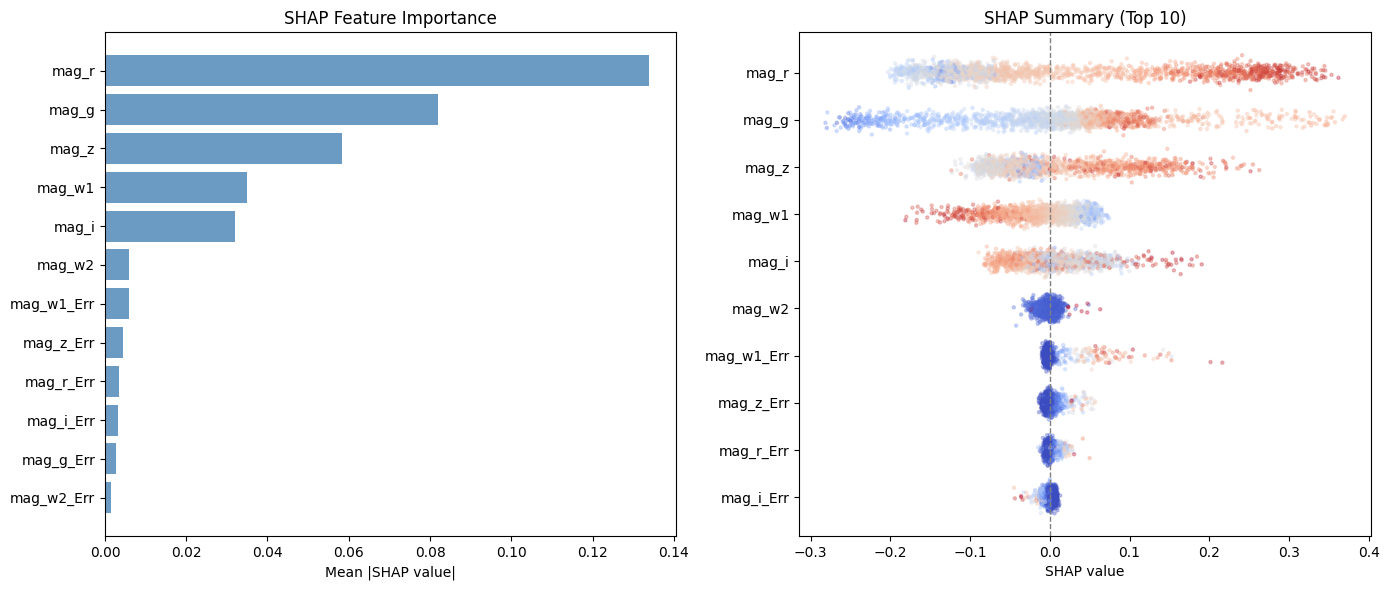


SHAP vs Permutation Importance 对比
 rank    feature  importance_normalized
    1      mag_r               1.000000
    2      mag_g               0.612390
    3      mag_z               0.434942
    4     mag_w1               0.261804
    5      mag_i               0.238318
    6     mag_w2               0.044488
    7 mag_w1_Err               0.044288
    8  mag_z_Err               0.033865
    9  mag_r_Err               0.026306
   10  mag_i_Err               0.023703
   11  mag_g_Err               0.020047
   12 mag_w2_Err               0.010368


In [213]:
# ============ SHAP Feature Importance ============
import shap

def compute_shap_importance(inference, data_path, n_background=100, n_samples=1000, random_state=42):
    """
    使用 SHAP 计算特征重要性
    
    SHAP (SHapley Additive exPlanations) 基于博弈论，能更好地处理特征相关性问题
    
    Parameters:
    -----------
    inference : PhotozBinInference
        模型推理对象
    data_path : str
        数据路径
    n_background : int
        背景样本数量（用于计算期望值）
    n_samples : int
        计算 SHAP 值的样本数量
    random_state : int
        随机种子
    
    Returns:
    --------
    shap_values : array
        SHAP 值 [n_samples, n_features]
    X_test : array
        测试样本特征
    feature_names : list
        特征名称列表
    mean_abs_shap : array
        平均绝对 SHAP 值（特征重要性）
    """
    np.random.seed(random_state)
    
    # 加载数据
    ds = inference._create_dataset(data_path, mode='validation')
    X = ds.features
    feature_names = ds.feature_cols
    bin_centers = ds.bin_centers
    
    print(f"数据集大小: {X.shape[0]} 样本, {X.shape[1]} 特征")
    print(f"背景样本: {n_background}, 测试样本: {n_samples}")
    
    # 随机采样
    bg_idx = np.random.choice(len(X), min(n_background, len(X)), replace=False)
    test_idx = np.random.choice(len(X), min(n_samples, len(X)), replace=False)
    X_background = X[bg_idx]
    X_test = X[test_idx]
    
    # 定义预测函数（输出红移期望值）
    def predict_fn(x):
        x_tensor = torch.FloatTensor(x).to(inference.device)
        inference.model.eval()
        with torch.no_grad():
            logits = inference.model(x_tensor).cpu().numpy()
        e_x = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        probs = e_x / e_x.sum(axis=1, keepdims=True)
        return (probs * bin_centers).sum(axis=1)
    
    # 创建 SHAP 解释器
    print("\n创建 SHAP 解释器...")
    explainer = shap.KernelExplainer(predict_fn, X_background)
    
    # 计算 SHAP 值
    print("计算 SHAP 值（这可能需要几分钟）...")
    shap_values = explainer.shap_values(X_test, silent=True)
    
    # 计算平均绝对 SHAP 值作为特征重要性
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    print("\n特征重要性 (Mean |SHAP|):")
    sorted_idx = np.argsort(mean_abs_shap)[::-1]
    for i, idx in enumerate(sorted_idx):
        print(f"  [{i+1:2d}] {feature_names[idx]:20s}: {mean_abs_shap[idx]:.6f}")
    
    return shap_values, X_test, feature_names, mean_abs_shap


def save_shap_importance(shap_values, X_test, feature_names, mean_abs_shap, save_dir):
    """保存 SHAP 特征重要性结果"""
    file_path = f"{save_dir}/shap_feature_importance.h5"
    with h5py.File(file_path, 'w') as f:
        f.create_dataset('shap_values', data=shap_values, compression='gzip')
        f.create_dataset('X_test', data=X_test, compression='gzip')
        f.create_dataset('feature_names', data=np.array(feature_names, dtype='S'))
        f.create_dataset('mean_abs_shap', data=mean_abs_shap)
        f.create_dataset('mean_abs_shap_normalized', data=mean_abs_shap / mean_abs_shap.max())
    print(f"\nSHAP 结果已保存到: {file_path}")
    
    # 创建 DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': mean_abs_shap,
        'importance_normalized': mean_abs_shap / mean_abs_shap.max()
    })
    importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
    importance_df['rank'] = importance_df.index + 1
    return importance_df


def plot_shap_importance(shap_values, X_test, feature_names, save_path=None):
    """绘制 SHAP 特征重要性图"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Bar plot (平均绝对 SHAP 值)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[::-1][:15]  # Top 15
    
    ax = axes[0]
    y_pos = np.arange(len(sorted_idx))
    ax.barh(y_pos, mean_abs_shap[sorted_idx], color='steelblue', alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([feature_names[i] for i in sorted_idx])
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('SHAP Feature Importance')
    
    # 2. Summary plot (SHAP 值分布)
    ax = axes[1]
    # 简化版 summary plot
    for i, idx in enumerate(sorted_idx[:10]):  # Top 10
        shap_feat = shap_values[:, idx]
        ax.scatter(shap_feat, np.ones(len(shap_feat)) * i + np.random.randn(len(shap_feat)) * 0.1,
                   c=X_test[:, idx], cmap='coolwarm', alpha=0.3, s=5)
    ax.set_yticks(range(10))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx[:10]])
    ax.invert_yaxis()
    ax.set_xlabel('SHAP value')
    ax.set_title('SHAP Summary (Top 10)')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存: {save_path}")
    plt.show()


# ============ 计算 SHAP 特征重要性 ============
print("=" * 60)
print("SHAP Feature Importance Analysis")
print("=" * 60)

inference = PhotozBinInference(model_dir=EXPERIMENT_DIR)
shap_values, X_test, feature_names, mean_abs_shap = compute_shap_importance(
    inference, TESTSET_PATH, 
    n_background=200,   # 背景样本数
    n_samples=2000,     # 测试样本数（增大可提高精度但更慢）
    random_state=42
)

# 保存结果
shap_df = save_shap_importance(
    shap_values, X_test, feature_names, mean_abs_shap,
    save_dir=CALIBRATOR_DIR
)

# 绘图
plot_shap_importance(
    shap_values, X_test, feature_names,
    save_path=f"{CALIBRATOR_DIR}/shap_feature_importance.jpg"
)

# 显示排名对比
print("\n" + "=" * 60)
print("SHAP vs Permutation Importance 对比")
print("=" * 60)
print(shap_df[['rank', 'feature', 'importance_normalized']].head(15).to_string(index=False))

# check

In [55]:
test_df = cu.readfile(TESTSET_PATH)
path = f"{CALIBRATOR_DIR}/predictions_test.fits"
test_pred_df_tsc = cu.readfile(path)
path = f"{EXPERIMENT_DIR}/predictions_test.fits"
test_pred_df = cu.readfile(path)

z_spec = test_df['z'].values
z_pred = test_pred_df['pred'].values
z_pred_tsc = test_pred_df_tsc['pred'].values
z_wen = test_df['phot_z'].values

In [56]:
print(f"Arrays identical: {np.allclose(z_pred, z_pred_tsc)}")
print(f"Same object: {z_pred is z_pred_tsc}")
print(f"Max difference: {np.max(np.abs(z_pred - z_pred_tsc))}")

Arrays identical: False
Same object: False
Max difference: 0.16476336062750008


In [57]:
metrics_wen = cu.evaluate_redshift_quality(z_spec, z_wen)
metrics_pred = cu.evaluate_redshift_quality(z_spec, z_pred)
metrics_pred_tsc = cu.evaluate_redshift_quality(z_spec, z_pred_tsc)

pd.set_option('display.float_format', '{:.5f}'.format)
print(pd.DataFrame([metrics_wen, metrics_pred, metrics_pred_tsc], index=['wen', 'pred', 'pred_tsc']))

          mean_bias  std_dev     mad  outlier_fraction
wen         0.00163  0.02838 0.01808           0.00933
pred       -0.00206  0.02520 0.01689           0.00575
pred_tsc   -0.00150  0.02492 0.01635           0.00592


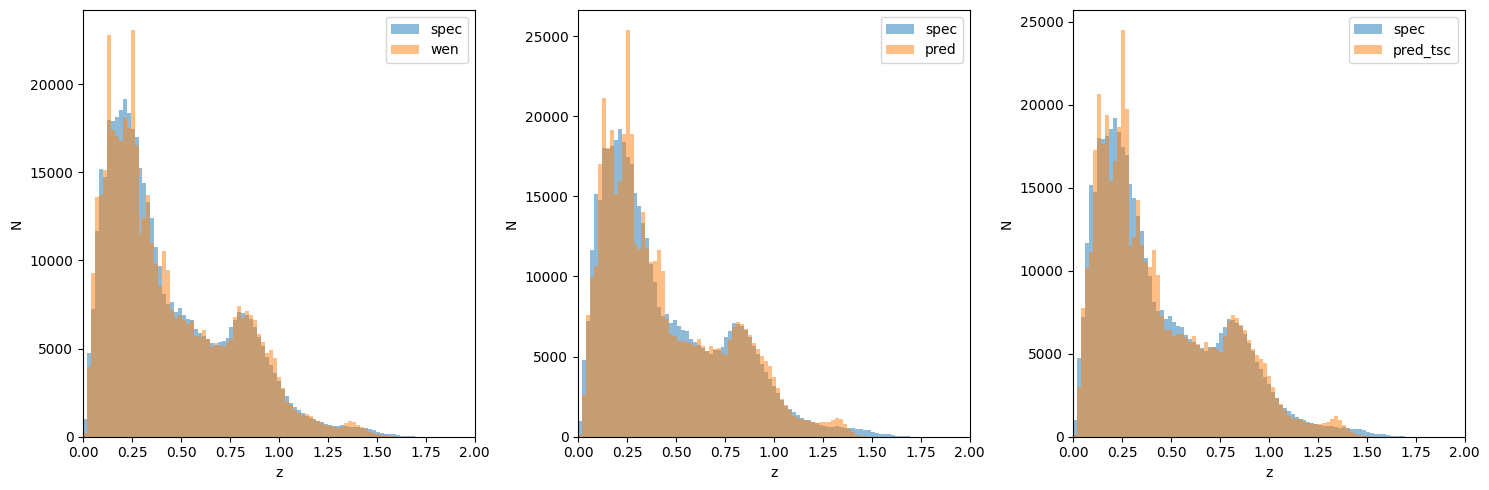

In [58]:
bins = np.linspace(0, 2, 100)
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.hist(z_spec, bins=bins, alpha=0.5, label='spec')
plt.hist(z_wen, bins=bins, alpha=0.5, label='wen')
plt.xlabel('z')
plt.ylabel('N')
plt.xlim(0, 2)
plt.legend()

plt.subplot(132)
plt.hist(z_spec, bins=bins, alpha=0.5, label='spec')
plt.hist(z_pred, bins=bins, alpha=0.5, label='pred')
plt.xlabel('z')
plt.ylabel('N')
plt.xlim(0, 2)
plt.legend()

plt.subplot(133)
plt.hist(z_spec, bins=bins, alpha=0.5, label='spec')
plt.hist(z_pred_tsc, bins=bins, alpha=0.5, label='pred_tsc')
plt.xlabel('z')
plt.ylabel('N')
plt.xlim(0, 2)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# check calibration
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
infer = PhotozBinInference(model_dir=EXPERIMENT_DIR, 
                           device=device, batch_size=4096)
calibrator_path = f"{EXPERIMENT_DIR}/test/calibrator_T0.9.pkl"
os.makedirs(os.path.dirname(calibrator_path), exist_ok=True)
infer.calibrate(data_source=TESTSET_PATH, temperature=0.9, save_path=calibrator_path)
infer.load_calibrator(calibrator_path)

save_path = f'{EXPERIMENT_DIR}/test/predictions_test_prob.h5'
infer.predict_probabilities_chunked(TESTSET_PATH, save_path,
                                    chunk_size=1000000,
                                    batch_size=4096,
                                    compression='gzip',
                                    apply_calibration=True)

Original bins: 400, Coarse bins for visualization: 400


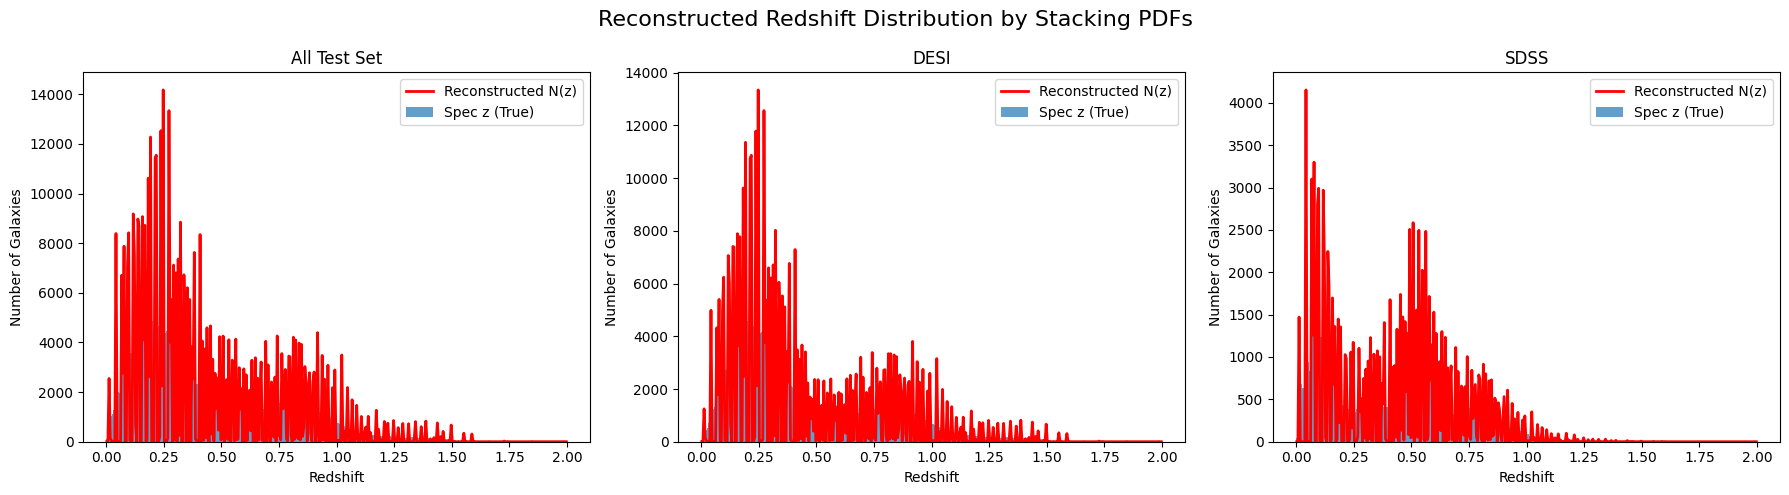

In [28]:
# stack PDF for testset
path = f"{CALIBRATOR_DIR}/predictions_test.fits"
res_df = cu.readfile(path)
path = '../data/DESIDR1_xSDSSDR19_xlsdr10phot_test.fits'
phot_df = cu.readfile(path)

all_labels = res_df['label'].values

path = f"{EXPERIMENT_DIR}/test/predictions_test_prob.h5"
with h5py.File(path, 'r') as f:
    all_probs = f['probabilities'][:] 
    bin_centers = f['bin_centers'][:] 
    bin_edges = f['bin_edges'][:]

# 定义粗 bin（用于可视化）
N_COARSE_BINS = 400  # 将 400 个细 bin 合并成 40 个粗 bin
z_min, z_max = bin_edges[0], bin_edges[-1]
coarse_edges = np.linspace(z_min, z_max, N_COARSE_BINS + 1)
coarse_centers = 0.5 * (coarse_edges[:-1] + coarse_edges[1:])
coarse_width = coarse_edges[1] - coarse_edges[0]

def rebin_stacked_prob(stack_prob, fine_centers, coarse_edges):
    """将细 bin 的 stacked prob 合并到粗 bin"""
    n_coarse = len(coarse_edges) - 1
    coarse_prob = np.zeros(n_coarse)
    for i in range(n_coarse):
        mask = (fine_centers >= coarse_edges[i]) & (fine_centers < coarse_edges[i+1])
        coarse_prob[i] = stack_prob[mask].sum()
    return coarse_prob

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
stack_prob_all = np.sum(all_probs, axis=0)
stack_prob_all_coarse = rebin_stacked_prob(stack_prob_all, bin_centers, coarse_edges)
hist_all, _ = np.histogram(all_labels, bins=coarse_edges)
stack_prob_all_normalized = stack_prob_all_coarse * (np.sum(hist_all) / np.sum(stack_prob_all_coarse))

plt.bar(coarse_centers, hist_all, width=coarse_width, alpha=0.7, label='Spec z (True)')
plt.plot(coarse_centers, stack_prob_all_normalized, 'r-', linewidth=2, label='Reconstructed N(z)')
plt.xlabel('Redshift')
plt.ylabel('Number of Galaxies')
plt.title('All Test Set')
plt.legend()

plt.subplot(1, 3, 2)
desi_idx = np.where(phot_df['DESI_TARGETID'].fillna(0) > 0)[0]
desi_labels = all_labels[desi_idx]
desi_probs = all_probs[desi_idx]
desi_stack_prob = np.sum(desi_probs, axis=0)
desi_stack_prob_coarse = rebin_stacked_prob(desi_stack_prob, bin_centers, coarse_edges)
hist_desi, _ = np.histogram(desi_labels, bins=coarse_edges)
desi_stack_prob_normalized = desi_stack_prob_coarse * (np.sum(hist_desi) / np.sum(desi_stack_prob_coarse))

plt.bar(coarse_centers, hist_desi, width=coarse_width, alpha=0.7, label='Spec z (True)')
plt.plot(coarse_centers, desi_stack_prob_normalized, 'r-', linewidth=2, label='Reconstructed N(z)')
plt.xlabel('Redshift')
plt.ylabel('Number of Galaxies')
plt.title('DESI')
plt.legend()

plt.subplot(1, 3, 3)
sdss_idx = np.where(phot_df['SDSS_specobjid'].fillna(0) > 0)[0]
sdss_labels = all_labels[sdss_idx]
sdss_probs = all_probs[sdss_idx]
sdss_stack_prob = np.sum(sdss_probs, axis=0)
sdss_stack_prob_coarse = rebin_stacked_prob(sdss_stack_prob, bin_centers, coarse_edges)
hist_sdss, _ = np.histogram(sdss_labels, bins=coarse_edges)
sdss_stack_prob_normalized = sdss_stack_prob_coarse * (np.sum(hist_sdss) / np.sum(sdss_stack_prob_coarse))

plt.bar(coarse_centers, hist_sdss, width=coarse_width, alpha=0.7, label='Spec z (True)')
plt.plot(coarse_centers, sdss_stack_prob_normalized, 'r-', linewidth=2, label='Reconstructed N(z)')
plt.xlabel('Redshift')
plt.ylabel('Number of Galaxies')
plt.title('SDSS')
plt.legend()

plt.suptitle('Reconstructed Redshift Distribution by Stacking PDFs', fontsize=16)
plt.tight_layout()

path = f"{EXPERIMENT_DIR}/test/BinningANN_stack_pdf.png"
plt.savefig(path, dpi=300)
print(f"Original bins: {len(bin_centers)}, Coarse bins for visualization: {N_COARSE_BINS}")

# 检查对比Zhou+21

In [2]:
import numpy as np
import pandas as pd
import torch
from photoz_bin import PhotozBinInference


def predict_photoz(
    df: pd.DataFrame,
    model_dir: str,
    calibrator_path: str = None,
    device: str = 'cuda:0',
    batch_size: int = 4096
) -> pd.DataFrame:
    """
    使用校准后的模型对 DataFrame 进行测光红移估计。
    
    Parameters
    ----------
    df : pd.DataFrame
        包含测光特征的 DataFrame
    model_dir : str
        模型目录路径 (包含 config.yaml, scaler.pkl, best_model.pt)
    calibrator_path : str, optional
        校准器路径 (calibrator.pkl)。如果为 None，则不使用温度校准
    device : str, default='cuda:0'
        计算设备
    batch_size : int, default=4096
        批处理大小
    
    Returns
    -------
    pd.DataFrame
        包含以下列的 DataFrame:
        - z_mean: 红移期望值 (概率分布的加权平均)
        - z_std: 红移标准差 (概率分布的加权标准差)
        - z_mode: 红移众数 (概率最大的 bin 对应的红移值)
    
    Example
    -------
    >>> model_dir = "./DESIDR1_xSDSSDR19/testLSgrzW1W2+PSi/Onlygrz"
    >>> calibrator_path = f"{model_dir}/TempScalingCalib/calibrator.pkl"
    >>> result = predict_photoz(df, model_dir, calibrator_path)
    >>> print(result[['z_mean', 'z_std', 'z_mode']].head())
    """
    # 初始化推理对象
    infer = PhotozBinInference(
        model_dir=model_dir,
        device=device,
        batch_size=batch_size
    )

    # 加载校准器 (如果提供)
    if calibrator_path is not None:
        infer.load_calibrator(calibrator_path)

    # 获取完整概率分布
    result = infer.predict_probabilities(
        data_source=df,
        batch_size=batch_size,
        apply_calibration=(calibrator_path is not None)
    )

    probs = result['probabilities']       # (n_samples, n_bins)
    bin_centers = result['bin_centers']   # (n_bins,)
    z_mean = result['expectation']        # (n_samples,)

    # 计算 z_std: sqrt(sum(p * (z - mean)^2))
    z_diff = bin_centers[np.newaxis, :] - z_mean[:, np.newaxis]  # (n_samples, n_bins)
    z_var = np.sum(probs * z_diff**2, axis=1)
    z_std = np.sqrt(z_var)

    # 计算 z_mode: 概率最大的 bin 对应的红移值
    mode_idx = np.argmax(probs, axis=1)
    z_mode = bin_centers[mode_idx]

    # 返回 DataFrame
    return pd.DataFrame({
        'z_mean': z_mean,
        'z_std': z_std,
        'z_mode': z_mode
    })
    
    
import cosmic.utils as cu
path = '../data/DESIDR1_xSDSSDR19_xlsdr10phot_test.fits'
df = cu.readfile(path)

model_dir = "./DESIDR1_xSDSSDR19/testFeature/LSDR10_Mag&MagErr"
calibrator_path = f"{model_dir}/TempScalingCalib/calibrator.pkl"

result = predict_photoz(df, model_dir, calibrator_path)
df[['z_mean', 'z_std', 'z_mode']] = result

metrics = cu.evaluate_redshift_quality(df['z'], df['z_mode'])
print(metrics)

Calibrator loaded: T=0.8825


{'mean_bias': np.float64(-8.514385741000977e-05), 'std_dev': np.float64(0.02680122158051626), 'mad': np.float64(0.016723200543247073), 'outlier_fraction': np.float64(0.008981270309209336)}


测试原始星等

In [7]:
import cosmic.utils as cu
path = '../data/compareToZhou21/DESIDR1_xSDSSDR19_xlsdr10phot_test_xlsdr9x10loc.fits'
df_raw = cu.readfile(path)
rename_cols = {'uid_1': 'uid', 'ra_1': 'ra', 'dec_1': 'dec'}

cols = [
    'uid', 'ra', 'dec', 'z', 'zErr',
    'DESI_TARGETID', 'DESI_RA', 'DESI_DEC', 'DESI_Z', 'DESI_ZERR',
    'DESI_DELTACHI2', 'DESI_DESI_TARGET', 'DESI_BGS_TARGET',
    'DESI_PRIORITY', 'SDSS_specobjid', 'SDSS_ra', 'SDSS_dec', 'SDSS_z',
    'SDSS_zErr', 'phot_z', 'phot_zErr', 'spec_z', 'mag_g', 'mag_g_Err',
    'mag_r', 'mag_r_Err', 'mag_i', 'mag_i_Err', 'mag_z', 'mag_z_Err',
    'mag_w1', 'mag_w1_Err', 'mag_w2', 'mag_w2_Err', 'mstar', 'BCG_flag',
]
df_raw = df_raw.rename(columns=rename_cols)[cols]

In [10]:
df = df_raw.copy().set_index('uid')

for i in range(72):
    backg_cols = [
        'z_phot_mean_grz', 'z_phot_median_grz', 'z_phot_std_grz', 
        'z_phot_mean_i', 'z_phot_median_i', 'z_phot_std_i',
        'dered_mag_g', 'dered_mag_r', 'dered_mag_i', 
        'dered_mag_z', 'dered_mag_w1', 'dered_mag_w2',
        'snr_g', 'snr_r', 'snr_i', 'snr_z', 'snr_w1', 'snr_w2',
    ]
    path = f'/home/tiandc/Data/LegacySurveys/DR9x10/clean/lsdr9x10_gal_clean_{i:02d}.fits'
    backgal = cu.readfile(path).set_index('uid')
    
    common_idx = backgal.index.intersection(df.index)
    df.loc[common_idx, backg_cols] = backgal.loc[common_idx, backg_cols]
    
    print(f"fid {i:02d}: {len(common_idx)}")
    
output_path = '../data/compareToZhou21/DESIDR1_xSDSSDR19_xlsdr10phot_test_xlsdr9x10photMag.fits'
df_save = df.reset_index()
cu.savefile(df_save, output_path)

fid 00: 3518
fid 01: 3395
fid 02: 4640
fid 03: 5714
fid 04: 6563
fid 05: 5249
fid 06: 6761
fid 07: 5717
fid 08: 5003
fid 09: 4743
fid 10: 4289
fid 11: 5855
fid 12: 6969
fid 13: 7688
fid 14: 4111
fid 15: 78
fid 16: 0
fid 17: 0
fid 18: 0
fid 19: 0
fid 20: 0
fid 21: 0
fid 22: 1374
fid 23: 4898
fid 24: 5556
fid 25: 9014
fid 26: 8802
fid 27: 7756
fid 28: 8912
fid 29: 8944
fid 30: 6201
fid 31: 11105
fid 32: 11015
fid 33: 10069
fid 34: 10083
fid 35: 7692
fid 36: 5677
fid 37: 7816
fid 38: 9883
fid 39: 9038
fid 40: 11070
fid 41: 10735
fid 42: 8440
fid 43: 6282
fid 44: 2832
fid 45: 7833
fid 46: 4973
fid 47: 5722
fid 48: 4459
fid 49: 7158
fid 50: 5322
fid 51: 2782
fid 52: 303
fid 53: 0
fid 54: 0
fid 55: 0
fid 56: 0
fid 57: 0
fid 58: 0
fid 59: 0
fid 60: 0
fid 61: 0
fid 62: 3731
fid 63: 4550
fid 64: 166
fid 65: 3700
fid 66: 3105
fid 67: 3171
fid 68: 766
fid 69: 3616
fid 70: 1897
fid 71: 3385


In [51]:
mask = df_save['dered_mag_w2'] < 0
df_save[mask]

,uid,ra,dec,z,zErr,DESI_TARGETID,DESI_RA,DESI_DEC,DESI_Z,DESI_ZERR,...,dered_mag_i,dered_mag_z,dered_mag_w1,dered_mag_w2,snr_g,snr_r,snr_i,snr_z,snr_w1,snr_w2


In [70]:
path = '../data/compareToZhou21/DESIDR1_xSDSSDR19_xlsdr10phot_test_xlsdr9x10photMag.fits'
df = cu.readfile(path)

cols_rename = [
    'mag_g', 'mag_g_Err', 'mag_r', 'mag_r_Err', 'mag_i', 'mag_i_Err',
    'mag_z', 'mag_z_Err', 'mag_w1', 'mag_w1_Err', 'mag_w2', 'mag_w2_Err',
]
cols_renamed = ['wen_' + col for col in cols_rename]
df = df.rename(columns=dict(zip(cols_rename, cols_renamed)))


In [71]:
df.columns

Index(['uid', 'ra', 'dec', 'z', 'zErr', 'DESI_TARGETID', 'DESI_RA', 'DESI_DEC',
       'DESI_Z', 'DESI_ZERR', 'DESI_DELTACHI2', 'DESI_DESI_TARGET',
       'DESI_BGS_TARGET', 'DESI_PRIORITY', 'SDSS_specobjid', 'SDSS_ra',
       'SDSS_dec', 'SDSS_z', 'SDSS_zErr', 'phot_z', 'phot_zErr', 'spec_z',
       'wen_mag_g', 'wen_mag_g_Err', 'wen_mag_r', 'wen_mag_r_Err', 'wen_mag_i',
       'wen_mag_i_Err', 'wen_mag_z', 'wen_mag_z_Err', 'wen_mag_w1',
       'wen_mag_w1_Err', 'wen_mag_w2', 'wen_mag_w2_Err', 'mstar', 'BCG_flag',
       'z_phot_mean_grz', 'z_phot_median_grz', 'z_phot_std_grz',
       'z_phot_mean_i', 'z_phot_median_i', 'z_phot_std_i', 'dered_mag_g',
       'dered_mag_r', 'dered_mag_i', 'dered_mag_z', 'dered_mag_w1',
       'dered_mag_w2', 'snr_g', 'snr_r', 'snr_i', 'snr_z', 'snr_w1', 'snr_w2'],
      dtype='object')

In [72]:
def snr_to_mag_err(snr):
    return 1.0857 / snr 

subdf = df.copy()
subdf['mag_g_Err'] = snr_to_mag_err(subdf['snr_g'])
subdf['mag_r_Err'] = snr_to_mag_err(subdf['snr_r'])
subdf['mag_i_Err'] = snr_to_mag_err(subdf['snr_i'])
subdf['mag_z_Err'] = snr_to_mag_err(subdf['snr_z'])
subdf['mag_w1_Err'] = snr_to_mag_err(subdf['snr_w1'])
subdf['mag_w2_Err'] = snr_to_mag_err(subdf['snr_w2'])

rename = {'dered_mag_g': 'mag_g', 'dered_mag_r': 'mag_r', 'dered_mag_i': 'mag_i', 
          'dered_mag_z': 'mag_z', 'dered_mag_w1': 'mag_w1', 'dered_mag_w2': 'mag_w2'}
subdf = subdf.rename(columns=rename)

mask = (subdf['mag_g'] > 0) & (subdf['mag_r'] > 0) & (subdf['mag_i'] > 0)
mask &= (subdf['mag_z'] > 0) & (subdf['mag_w1'] > 0) & (subdf['mag_w2'] > 0)
subdf = subdf[mask]

In [81]:
band = 'w1'
subdf[[f'wen_mag_{band}_Err', f'mag_{band}_Err']]

,wen_mag_w1_Err,mag_w1_Err
0,0.176,0.191362
1,0.050,0.016404
2,0.050,0.016747
3,0.050,0.008010
4,0.050,0.022962
...,...,...
330121,0.050,0.020327
330122,0.050,0.022306
330123,0.050,0.007250
330124,0.050,0.005593


In [82]:
np.std(subdf[f'wen_mag_{band}_Err']-subdf[f'mag_{band}_Err'])

np.float64(0.01823355746705139)

In [62]:
output_path = '../data/compareToZhou21/DESIDR1_xSDSSDR19_xlsdr10phot_test_xlsdr9x10photMag_delWen_rename.fits'
cu.savefile(subdf, output_path)

In [66]:
subdf[['mag_g', 'mag_r',
       'mag_i', 'mag_z', 'mag_w1', 'mag_w2', 'mag_g_Err', 'mag_r_Err', 'mag_i_Err',
       'mag_z_Err', 'mag_w1_Err', 'mag_w2_Err', 'snr_g','snr_r','snr_i','snr_z','snr_w1','snr_w2']]

,mag_g,mag_r,mag_i,mag_z,mag_w1,mag_w2,mag_g_Err,mag_r_Err,mag_i_Err,mag_z_Err,mag_w1_Err,mag_w2_Err,snr_g,snr_r,snr_i,snr_z,snr_w1,snr_w2
0,22.827414,22.688175,22.183868,21.900221,21.387974,22.416874,0.097841,0.087482,0.060043,0.079793,0.191362,1.180137,11.096581,12.410501,18.082043,13.606434,5.673554,0.919978
1,22.523129,21.063019,20.121212,19.713480,18.489004,19.297720,0.052969,0.022211,0.013393,0.006811,0.016404,0.071652,20.497042,48.880783,81.062691,159.404526,66.185791,15.152381
2,23.307436,21.908661,20.763908,20.164831,18.569510,19.039146,0.036280,0.016027,0.016924,0.005542,0.016747,0.054636,29.925943,67.740402,64.151840,195.906418,64.829712,19.871365
3,20.634691,19.131021,18.546394,18.188755,17.413996,17.725885,0.006044,0.002264,0.009042,0.001386,0.008010,0.020828,179.646790,479.570740,120.069489,783.232666,135.545029,52.125740
4,24.721100,22.450457,21.033098,20.468430,18.930357,19.527300,0.309569,0.058887,0.026313,0.023003,0.022962,0.086241,3.507129,18.437117,41.261089,47.197868,47.283035,12.589094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330121,18.040264,17.659842,17.522299,17.430780,18.233168,18.681454,0.003227,0.003353,0.009778,0.004859,0.020327,0.065015,336.468811,323.751953,111.035263,223.454666,53.411976,16.699118
330122,20.463188,19.445877,19.065907,18.836758,18.787928,19.151144,0.008966,0.005517,0.009858,0.005241,0.022306,0.066594,121.086121,196.806992,110.134857,207.160110,48.672405,16.303291
330123,19.399015,18.036295,17.608852,17.330942,17.229631,17.624422,0.005530,0.002576,0.003890,0.002139,0.007250,0.019717,196.320328,421.541138,279.123291,507.681183,149.752533,55.063850
330124,18.641701,17.614939,17.194183,16.908512,16.845247,17.167429,0.003396,0.001995,0.002925,0.001630,0.005593,0.013859,319.653656,544.131958,371.167389,666.126648,194.125900,78.341637


In [67]:
import numpy as np
import pandas as pd
import torch
from photoz_bin import PhotozBinInference


def predict_photoz(
    df: pd.DataFrame,
    model_dir: str,
    calibrator_path: str = None,
    device: str = 'cuda:0',
    batch_size: int = 4096
) -> pd.DataFrame:
    """
    使用校准后的模型对 DataFrame 进行测光红移估计。
    
    Parameters
    ----------
    df : pd.DataFrame
        包含测光特征的 DataFrame
    model_dir : str
        模型目录路径 (包含 config.yaml, scaler.pkl, best_model.pt)
    calibrator_path : str, optional
        校准器路径 (calibrator.pkl)。如果为 None，则不使用温度校准
    device : str, default='cuda:0'
        计算设备
    batch_size : int, default=4096
        批处理大小
    
    Returns
    -------
    pd.DataFrame
        包含以下列的 DataFrame:
        - z_mean: 红移期望值 (概率分布的加权平均)
        - z_std: 红移标准差 (概率分布的加权标准差)
        - z_mode: 红移众数 (概率最大的 bin 对应的红移值)
    
    Example
    -------
    >>> model_dir = "./DESIDR1_xSDSSDR19/testLSgrzW1W2+PSi/Onlygrz"
    >>> calibrator_path = f"{model_dir}/TempScalingCalib/calibrator.pkl"
    >>> result = predict_photoz(df, model_dir, calibrator_path)
    >>> print(result[['z_mean', 'z_std', 'z_mode']].head())
    """
    # 初始化推理对象
    infer = PhotozBinInference(
        model_dir=model_dir,
        device=device,
        batch_size=batch_size
    )

    # 加载校准器 (如果提供)
    if calibrator_path is not None:
        infer.load_calibrator(calibrator_path)

    # 获取完整概率分布
    result = infer.predict_probabilities(
        data_source=df,
        batch_size=batch_size,
        apply_calibration=(calibrator_path is not None)
    )

    probs = result['probabilities']       # (n_samples, n_bins)
    bin_centers = result['bin_centers']   # (n_bins,)
    z_mean = result['expectation']        # (n_samples,)

    # 计算 z_std: sqrt(sum(p * (z - mean)^2))
    z_diff = bin_centers[np.newaxis, :] - z_mean[:, np.newaxis]  # (n_samples, n_bins)
    z_var = np.sum(probs * z_diff**2, axis=1)
    z_std = np.sqrt(z_var)

    # 计算 z_mode: 概率最大的 bin 对应的红移值
    mode_idx = np.argmax(probs, axis=1)
    z_mode = bin_centers[mode_idx]

    # 返回 DataFrame
    return pd.DataFrame({
        'z_mean': z_mean,
        'z_std': z_std,
        'z_mode': z_mode
    })
    
    
import cosmic.utils as cu
path = '../data/compareToZhou21/DESIDR1_xSDSSDR19_xlsdr10phot_test_xlsdr9x10photMag_delWen_rename.fits'
df = cu.readfile(path)

model_dir = "./DESIDR1_xSDSSDR19/testFeature/LSDR10_Mag"
calibrator_path = f"{model_dir}/TempScalingCalib/calibrator.pkl"

result = predict_photoz(df, model_dir, calibrator_path)
df[['z_mean', 'z_std', 'z_mode']] = result

metrics = cu.evaluate_redshift_quality(df['z'], df['z_mean'])
print(metrics)

Calibrator loaded: T=0.8636
{'mean_bias': np.float64(0.00013437545673583462), 'std_dev': np.float64(0.027155396043115697), 'mad': np.float64(0.018677756970263065), 'outlier_fraction': np.float64(0.008422175163066035)}


In [68]:
metrics = cu.evaluate_redshift_quality(df['z'], df['z_mean'])
print(metrics)
metrics = cu.evaluate_redshift_quality(df['z'], df['z_phot_mean_i'])
print(metrics)

{'mean_bias': np.float64(0.00013437545673583462), 'std_dev': np.float64(0.027155396043115697), 'mad': np.float64(0.018677756970263065), 'outlier_fraction': np.float64(0.008422175163066035)}
{'mean_bias': np.float64(0.0003747257298898435), 'std_dev': np.float64(0.026523633427302507), 'mad': np.float64(0.018334067845796744), 'outlier_fraction': np.float64(0.0090523235205904)}


In [55]:
subdf.isnull().sum()

uid                       0
ra                        0
dec                       0
z                         0
zErr                      0
DESI_TARGETID          5760
DESI_RA                5760
DESI_DEC               5760
DESI_Z                 5760
DESI_ZERR              5760
DESI_DELTACHI2         5760
DESI_DESI_TARGET       5760
DESI_BGS_TARGET        5760
DESI_PRIORITY          5760
SDSS_specobjid            0
SDSS_ra              322808
SDSS_dec             322808
SDSS_z               322808
SDSS_zErr            322808
phot_z                    0
phot_zErr                 0
spec_z                    0
z_phot_mean_grz           0
z_phot_median_grz         0
z_phot_std_grz            0
z_phot_mean_i             0
z_phot_median_i           0
z_phot_std_i              0
mag_g                     0
mag_r                     0
mag_i                     0
mag_z                     0
mag_w1                    0
mag_w2                    0
snr_g                     0
snr_r               

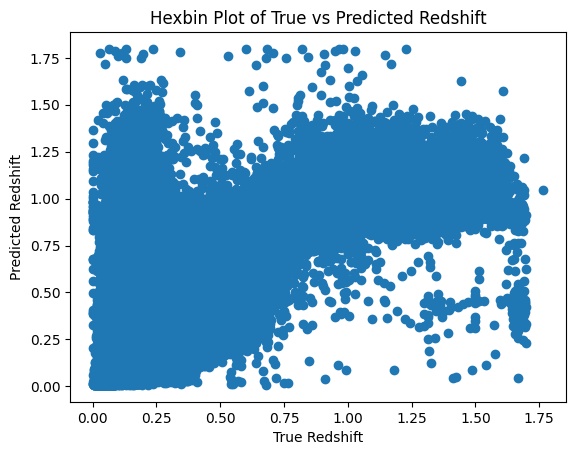

In [36]:
import matplotlib.pyplot as plt
plt.scatter(df['z'], df['z_mean'])
plt.xlabel('True Redshift')
plt.ylabel('Predicted Redshift')
plt.title('Hexbin Plot of True vs Predicted Redshift')
plt.show()